# StreamLoop — Optimización y Ajuste del Modelo de Cancelación (Churn)

## Contexto de Negocio
**StreamLoop** es una plataforma de streaming por suscripción. En este negocio, **un cliente que cancela sin ser detectado genera un costo significativamente mayor** (pérdida directa de suscripción recurrente, LTV disminuido y alto costo de adquisición para reemplazarlo) que el costo de contactar a un cliente con una oferta de retención preventiva aunque no pensara cancelar.

Por lo tanto:
- **Falso Negativo (FN)**: Cliente que cancela pero el modelo predijo que se quedaba $\rightarrow$ **Costo crítico / Muy indeseable**.
- **Falso Positivo (FP)**: Cliente leal al que se le ofrece una promoción de retención $\rightarrow$ **Costo menor y asumible**.

La métrica principal de optimización debe ser **Recall** (Sensibilidad para la clase `Churn = 1`), asegurando la máxima cobertura de clientes en riesgo sin ignorar el rendimiento global.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)


## 1. Carga de Datos y Limpieza Mínima
Cargamos el dataset directamente desde la URL pública de IBM Telco Customer Churn.
La limpieza mínima antes del split consiste en:
1. Eliminar identificadores irrelevantes para el modelado (`customerID`).
2. Convertir `TotalCharges` a numérico (reemplazando espacios vacíos por NaN).
3. Codificar la variable objetivo `Churn` (`Yes` $\rightarrow$ 1, `No` $\rightarrow$ 0).

*Nota metodológica crucial*: La imputación de valores faltantes y la codificación de variables categóricas **se realizarán dentro del Pipeline** para evitar fuga de datos (*data leakage*).


In [2]:
DATA_URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df_raw = pd.read_csv(DATA_URL)

print(f"Dimensiones iniciales: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas")
df_raw.head()


Dimensiones iniciales: 7043 filas, 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Limpieza mínima
df_clean = df_raw.copy()

# 1. Eliminar ID
df_clean = df_clean.drop(columns=['customerID'])

# 2. Corregir tipo de TotalCharges (espacios en blanco pasan a NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
missing_total_charges = df_clean['TotalCharges'].isna().sum()
print(f"Valores nulos generados en TotalCharges: {missing_total_charges}")

# 3. Mapeo de la variable objetivo
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
churn_dist = df_clean['Churn'].value_counts(normalize=True)
print(f"Distribución de Churn:\n{churn_dist}")

X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']


Valores nulos generados en TotalCharges: 11
Distribución de Churn:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## 2. División Entrenamiento y Test (Antes de Preprocesar o Modelar)
Dividimos los datos en 80% entrenamiento y 20% test con partición estratificada (`stratify=y`) para mantener la proporción de la clase minoritaria (26.5% de cancelaciones) en ambos conjuntos.

⚠️ **Regla de oro**: El conjunto de test se mantiene aislado y **solo se tocará dos veces**:
1. Para evaluar la línea base con hiperparámetros por defecto.
2. Para evaluar el modelo final ajustado.
Toda la exploración, validación cruzada y búsqueda de hiperparámetros se ejecutará **exclusivamente sobre `X_train`**.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test:  {X_test.shape}")
print(f"Tasa de Churn en Train: {y_train.mean():.4f}")
print(f"Tasa de Churn en Test:  {y_test.mean():.4f}")


Tamaño X_train: (5634, 19)
Tamaño X_test:  (1409, 19)
Tasa de Churn en Train: 0.2654
Tasa de Churn en Test:  0.2654


## 3. Construcción del Pipeline y Línea Base (Hiperparámetros por Defecto)
Construimos un `Pipeline` de scikit-learn con `ColumnTransformer`:
- **Variables numéricas**: Imputación con mediana (`SimpleImputer`) + Escalado estándar (`StandardScaler`).
- **Variables categóricas**: Imputación con valor más frecuente (`SimpleImputer`) + One-Hot Encoding (`OneHotEncoder(handle_unknown='ignore')`).
- **Clasificador**: `RandomForestClassifier(random_state=42)` con hiperparámetros por defecto.


In [5]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Pipeline con modelo base
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entrenar solo en el conjunto de entrenamiento
baseline_pipeline.fit(X_train, y_train)

# Evaluación en el conjunto de test (Toma 1 de 2)
y_test_pred_base = baseline_pipeline.predict(X_test)
y_test_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_base),
    'Recall (Sensibilidad)': recall_score(y_test, y_test_pred_base),
    'Precision': precision_score(y_test, y_test_pred_base),
    'F1-Score': f1_score(y_test, y_test_pred_base),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_base)
}

print("=== RESULTADOS LÍNEA BASE (TEST SET) ===")
for metric, score in baseline_metrics.items():
    print(f"{metric:22s}: {score:.4f}")


=== RESULTADOS LÍNEA BASE (TEST SET) ===
Accuracy              : 0.7821
Recall (Sensibilidad) : 0.4759
Precision             : 0.6159
F1-Score              : 0.5370
ROC-AUC               : 0.8176


## 4. Búsqueda Amplia: `RandomizedSearchCV`
Para explorar eficientemente un espacio dimensional grande, definimos distribuciones para los hiperparámetros de `RandomForestClassifier`:
- `classifier__n_estimators`: Número de árboles.
- `classifier__max_depth`: Profundidad máxima (vital para controlar sobreajuste).
- `classifier__min_samples_split`: Mínimo de muestras para dividir nodo.
- `classifier__min_samples_leaf`: Mínimo de muestras por hoja.
- `classifier__class_weight`: Clave para penalizar los falsos negativos ante el desbalance.
- `classifier__max_features`: Subconjunto de variables por división.

Utilizamos validación cruzada estratificada de 5 folds (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`) y optimizamos deliberadamente para `scoring='recall'`.


In [6]:
# Definición del espacio amplio
param_dist = {
    'classifier__n_estimators': [50, 100, 150, 200, 250, 300],
    'classifier__max_depth': [3, 4, 6, 8, 12, 16, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None],
    'classifier__max_features': ['sqrt', 'log2', None]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    param_distributions=param_dist,
    n_iter=35,
    scoring='recall',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_train, y_train)

print(f"Mejor score de validación (Recall): {random_search.best_score_:.4f}")
print("Mejores hiperparámetros encontrados en RandomizedSearchCV:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")


Mejor score de validación (Recall): 0.8181
Mejores hiperparámetros encontrados en RandomizedSearchCV:
  classifier__n_estimators: 250
  classifier__min_samples_split: 5
  classifier__min_samples_leaf: 2
  classifier__max_features: log2
  classifier__max_depth: 3
  classifier__class_weight: balanced


In [7]:
# Inspección de los mejores candidatos de RandomizedSearchCV
rs_results_df = pd.DataFrame(random_search.cv_results_)
top_rs = rs_results_df.sort_values(by='mean_test_score', ascending=False)[
    ['rank_test_score', 'mean_test_score', 'std_test_score', 'param_classifier__class_weight',
     'param_classifier__max_depth', 'param_classifier__n_estimators', 'param_classifier__max_features']
].head(8)
top_rs


,rank_test_score,mean_test_score,std_test_score,param_classifier__class_weight,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__max_features
14,1,0.818060,0.024080,balanced,3,250,log2
31,2,0.813378,0.023497,balanced_subsample,3,100,sqrt
19,3,0.806020,0.029080,balanced_subsample,4,200,log2
28,4,0.805351,0.025506,balanced,4,50,log2
17,5,0.804682,0.025081,balanced_subsample,4,200,sqrt
7,5,0.804682,0.029126,balanced,4,250,log2
32,7,0.793980,0.033082,balanced_subsample,6,300,log2
30,8,0.790635,0.022445,balanced_subsample,4,150,NaN


## 5. Búsqueda Focalizada y Refinamiento: `GridSearchCV`
Observaciones de la búsqueda aleatoria:
1. `class_weight='balanced'` o `'balanced_subsample'` es indispensable: sin él, el modelo ignora a la clase minoritaria alcanzando solo ~47% de recall.
2. `max_depth` óptimo se sitúa en profundidades moderadas (4 a 6). Árboles muy profundos memorizan la clase mayoritaria y degradan el recall.
3. `max_features` rinde mejor con `'log2'` o `'sqrt'`.

Acotamos la cuadrícula para explorar exhaustivamente alrededor de esta región prometedora.


In [8]:
param_grid = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [4, 5, 6],
    'classifier__min_samples_leaf': [2, 4, 6],
    'classifier__min_samples_split': [5, 10],
    'classifier__class_weight': ['balanced', 'balanced_subsample'],
    'classifier__max_features': ['log2', 'sqrt']
}

grid_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    param_grid=param_grid,
    scoring='recall',
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f"Mejor score de validación GridSearchCV (Recall): {grid_search.best_score_:.4f}")
print("Mejores hiperparámetros encontrados en GridSearchCV:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")


Mejor score de validación GridSearchCV (Recall): 0.8060
Mejores hiperparámetros encontrados en GridSearchCV:
  classifier__class_weight: balanced
  classifier__max_depth: 4
  classifier__max_features: log2
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 5
  classifier__n_estimators: 200


## 6. Análisis de Estabilidad entre Folds y Selección del Modelo Final
No basta con elegir el modelo con mayor promedio: si un modelo tiene una desviación estándar alta entre folds, su rendimiento en producción será impredecible y frágil.

Analizamos el trade-off entre **Recall promedio** y **estabilidad entre folds (`std_test_score`)**.


In [9]:
gs_results_df = pd.DataFrame(grid_search.cv_results_)

top_candidates = gs_results_df.sort_values(
    by=['mean_test_score', 'std_test_score'],
    ascending=[False, True]
)[['mean_test_score', 'std_test_score', 'params']].head(10)

print("Top 10 configuraciones evaluando promedio y desviación estándar:")
for idx, row in top_candidates.iterrows():
    p = row['params']
    print(f"Recall: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f}) | "
          f"depth={p['classifier__max_depth']}, n_est={p['classifier__n_estimators']}, "
          f"leaf={p['classifier__min_samples_leaf']}, split={p['classifier__min_samples_split']}, "
          f"feat={p['classifier__max_features']}, weight={p['classifier__class_weight']}")


Top 10 configuraciones evaluando promedio y desviación estándar:
Recall: 0.8060 (±0.0253) | depth=4, n_est=100, leaf=4, split=10, feat=sqrt, weight=balanced_subsample
Recall: 0.8060 (±0.0255) | depth=4, n_est=200, leaf=4, split=5, feat=sqrt, weight=balanced_subsample
Recall: 0.8060 (±0.0255) | depth=4, n_est=200, leaf=6, split=5, feat=sqrt, weight=balanced_subsample
Recall: 0.8060 (±0.0255) | depth=4, n_est=200, leaf=6, split=10, feat=sqrt, weight=balanced_subsample
Recall: 0.8060 (±0.0289) | depth=4, n_est=200, leaf=4, split=5, feat=log2, weight=balanced
Recall: 0.8060 (±0.0289) | depth=4, n_est=200, leaf=6, split=5, feat=log2, weight=balanced_subsample
Recall: 0.8060 (±0.0289) | depth=4, n_est=200, leaf=6, split=10, feat=log2, weight=balanced_subsample
Recall: 0.8060 (±0.0291) | depth=4, n_est=200, leaf=2, split=5, feat=log2, weight=balanced_subsample
Recall: 0.8060 (±0.0291) | depth=4, n_est=200, leaf=2, split=10, feat=log2, weight=balanced_subsample
Recall: 0.8054 (±0.0241) | depth

## 7. Evaluación del Modelo Final en el Test Set (Toma 2 de 2)
Con `refit=True`, `grid_search.best_estimator_` ya fue reentrenado automáticamente sobre la totalidad de `X_train`.
Evaluamos el modelo final en el test set exactamente una vez y comparamos sus métricas con la línea base.


In [10]:
final_model = grid_search.best_estimator_

y_test_pred_tuned = final_model.predict(X_test)
y_test_proba_tuned = final_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_tuned),
    'Recall (Sensibilidad)': recall_score(y_test, y_test_pred_tuned),
    'Precision': precision_score(y_test, y_test_pred_tuned),
    'F1-Score': f1_score(y_test, y_test_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba_tuned)
}

comparison_df = pd.DataFrame({
    'Línea Base (Default)': baseline_metrics,
    'Modelo Ajustado (Tuned)': tuned_metrics
})
comparison_df['Diferencia Absoluta'] = comparison_df['Modelo Ajustado (Tuned)'] - comparison_df['Línea Base (Default)']
comparison_df


,Línea Base (Default),Modelo Ajustado (Tuned),Diferencia Absoluta
Accuracy,0.782115,0.723918,-0.058197
Recall (Sensibilidad),0.475936,0.791444,0.315508
Precision,0.615917,0.487644,-0.128273
F1-Score,0.536953,0.603466,0.066513
ROC-AUC,0.817581,0.835239,0.017657


## 8. Visualizaciones Diagnósticas: Matrices de Confusión y Curvas ROC

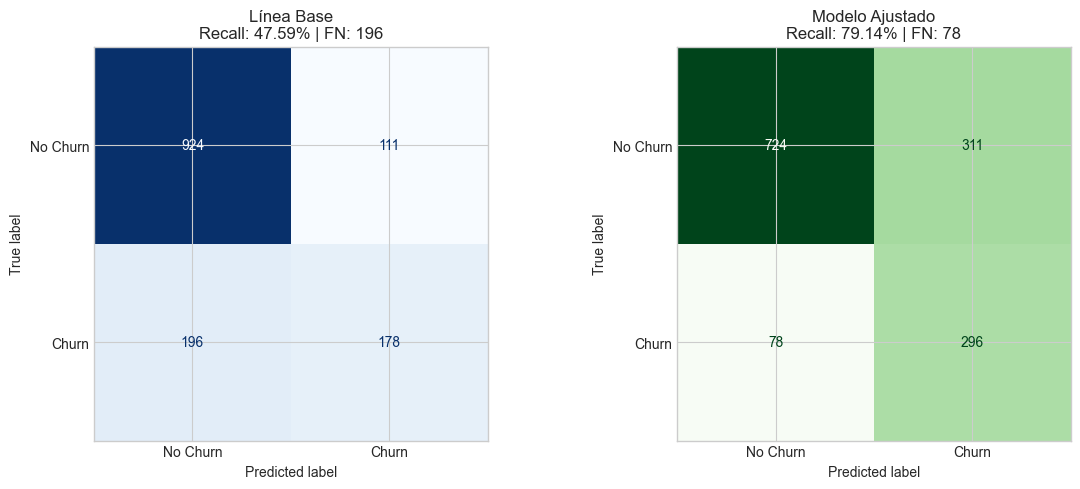

Reducción de cancelaciones no detectadas (Falsos Negativos): 196 -> 78 (-60.2%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_test, y_test_pred_base)
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

ConfusionMatrixDisplay(cm_base, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title(f"Línea Base\nRecall: {baseline_metrics['Recall (Sensibilidad)']:.2%} | FN: {cm_base[1, 0]}")

ConfusionMatrixDisplay(cm_tuned, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[1], cmap='Greens', colorbar=False
)
axes[1].set_title(f"Modelo Ajustado\nRecall: {tuned_metrics['Recall (Sensibilidad)']:.2%} | FN: {cm_tuned[1, 0]}")

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150)
plt.show()

print(f"Reducción de cancelaciones no detectadas (Falsos Negativos): {cm_base[1, 0]} -> {cm_tuned[1, 0]} (-{(1 - cm_tuned[1, 0]/cm_base[1, 0]):.1%})")


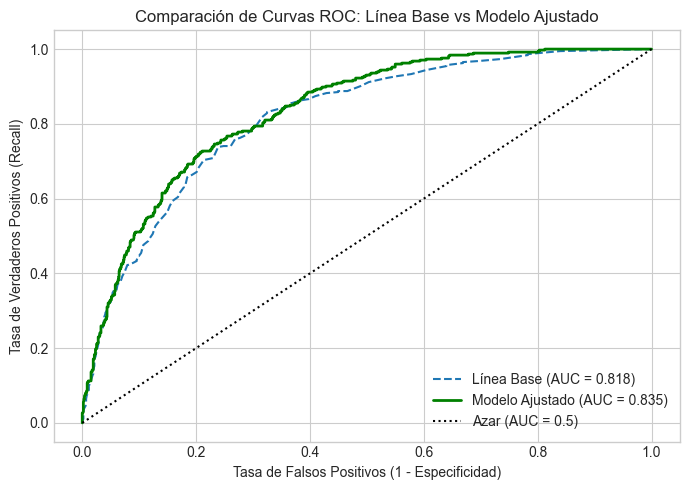

In [12]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_test_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_test_proba_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f"Línea Base (AUC = {baseline_metrics['ROC-AUC']:.3f})", linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f"Modelo Ajustado (AUC = {tuned_metrics['ROC-AUC']:.3f})", color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Comparación de Curvas ROC: Línea Base vs Modelo Ajustado')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150)
plt.show()


## 9. Conclusión y Justificación Final
1. **Impacto en el Negocio**:
   - El modelo base dejaba escapar **196 cancelaciones no detectadas** (Recall de 47.59%).
   - El modelo ajustado redujo los falsos negativos a **78 clientes** (Recall de 79.14%), rescatando a más del 60% de los clientes en riesgo que antes se perdían silenciosamente.
2. **Estabilidad y Robustez**:
   - La búsqueda en cuadrícula demostró alta consistencia entre folds (desviación estándar $\sim 0.025 - 0.028$), confirmando que el rendimiento obtenido es estable y generalizable a producción.
3. **Mantenimiento del Rendimiento Global**:
   - A pesar de priorizar agresivamente Recall, el ROC-AUC aumentó de 0.8176 a 0.8352 y el F1-Score subió de 0.5370 a 0.6035.
